# Shrimp Disease LiteRT/TFLite Inference

This notebook loads the trained `.tflite` / LiteRT classification models produced by `training_and_log_v2.ipynb` and `onnx_to_litert_conversion_ver2.ipynb`, applies the same preprocessing used during training/export, and runs inference on one image or a folder of images.

Expected Google Drive layout from the training/conversion notebooks:

- PyTorch-derived converted models: `/content/drive/MyDrive/onnx_models/litert_models/tflite/`
- PyTorch conversion report: `/content/drive/MyDrive/onnx_models/litert_models/reports/onnx_to_litert_conversion_report.csv`
- YOLO exported models: `/content/drive/MyDrive/shrimp_disease_images/baseline_model_comparison/yolo_runs/*/weights/best_saved_model/*.tflite`
- Optional YOLO/training report: `/content/drive/MyDrive/shrimp_disease_images/baseline_model_comparison/reports/baseline_model_comparison_summary.csv`

If your files are elsewhere, edit the path constants in the configuration cell below.

In [1]:
# Colab dependency cell. Run once after opening the notebook.
%pip -q install ai-edge-litert pandas pillow matplotlib tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 40.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Configuration

The class order is copied from the training notebook: `['Healthy', 'BG', 'WSSV', 'WSSV_BG']`. Keep this order unless you retrain with a different label mapping.

In [6]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
ALLOW_MULTIPLE_EXPORTS_PER_MODEL = False

CLASS_NAMES = ['Healthy', 'BG', 'WSSV', 'WSSV_BG']
IMG_SIZE = 224
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# PyTorch MobileNet/EfficientNet were trained with ImageNet normalization, exported to ONNX, then converted to LiteRT/TFLite.
PYTORCH_TFLITE_DIR = Path('/content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/tflite')
PYTORCH_CONVERSION_REPORT = Path('/content/drive/MyDrive/onnx_models/onnx_models/litert_models/reports/onnx_to_litert_conversion_report.csv')

# YOLO classification models were trained/exported through Ultralytics and use 0-1 image input.
BASELINE_ROOT = Path('/content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization')
BASELINE_SUMMARY = BASELINE_ROOT / 'reports' / 'baseline_model_comparison_summary.csv'
YOLO_TFLITE_GLOB = str(BASELINE_ROOT / 'yolo_runs' / '*' / 'weights' / 'best_saved_model' / '*.tflite')

# Put ad hoc images here, or change these paths before running the example cells.
SINGLE_IMAGE_PATH = Path('/content/drive/MyDrive/shrimp_disease_images/Processed_Rembg_Images/2. BG/BG-1-img-1.jpg')
BATCH_IMAGE_DIR = Path('/content/drive/MyDrive/shrimp_disease_images/baseline_model_comparison/yolo_dataset/test')
INFERENCE_OUTPUT_DIR = Path('/content/drive/MyDrive/shrimp_disease_images/inference_results')
INFERENCE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
try:
    from ai_edge_litert.interpreter import Interpreter
    INTERPRETER_BACKEND = 'ai_edge_litert'
except Exception:
    import tensorflow as tf
    Interpreter = tf.lite.Interpreter
    INTERPRETER_BACKEND = 'tensorflow.lite'

print(f'Using interpreter backend: {INTERPRETER_BACKEND}')

Using interpreter backend: ai_edge_litert


## Discover Available Models

The registry stores each model path and its preprocessing family. This matters because the converted PyTorch models expect ImageNet-normalized inputs, while the YOLO LiteRT exports expect 0-1 RGB inputs.

In [7]:
def discover_pytorch_tflite_models():
    models = []

    if PYTORCH_CONVERSION_REPORT.exists():
        report = pd.read_csv(PYTORCH_CONVERSION_REPORT)
        for _, row in report.iterrows():
            model_name = str(row.get('model', '')).strip()
            for col, suffix in [('float32_tflite_path', 'float32'), ('dynamic_tflite_path', 'dynamic_range')]:
                path_text = str(row.get(col, '')).strip()
                if path_text and path_text.lower() != 'nan':
                    path = Path(path_text)
                    if path.exists():
                        models.append({
                            'model_key': f'{model_name}_{suffix}',
                            'model_name': model_name,
                            'model_family': 'pytorch_imagenet',
                            'path': path,
                        })

    if PYTORCH_TFLITE_DIR.exists():
        known_paths = {str(item['path']) for item in models}
        for path in sorted(PYTORCH_TFLITE_DIR.glob('*.tflite')):
            if str(path) not in known_paths:
                models.append({
                    'model_key': path.stem,
                    'model_name': path.stem,
                    'model_family': 'pytorch_imagenet',
                    'path': path,
                })
    return models


def discover_yolo_tflite_models():
    models = []

    if BASELINE_SUMMARY.exists():
        summary = pd.read_csv(BASELINE_SUMMARY)
        if {'Model', 'Export Format', 'Export Path'}.issubset(summary.columns):
            for _, row in summary.iterrows():
                export_format = str(row.get('Export Format', '')).lower().strip()
                model_name = str(row.get('Model', '')).strip()
                path_text = str(row.get('Export Path', '')).strip()
                if export_format == 'tflite' and path_text and path_text.lower() != 'nan':
                    path = Path(path_text)
                    if path.exists():
                        models.append({
                            'model_key': model_name,
                            'model_name': model_name,
                            'model_family': 'yolo_ultralytics',
                            'path': path,
                        })

    known_paths = {str(item['path']) for item in models}
    for path in sorted(Path('/').glob(YOLO_TFLITE_GLOB.lstrip('/'))):
        if str(path) not in known_paths:
            model_name = path.parents[2].name if len(path.parents) >= 3 else path.stem
            models.append({
                'model_key': model_name,
                'model_name': model_name,
                'model_family': 'yolo_ultralytics',
                'path': path,
            })
    return models


def normalized_path_key(path):
    path = Path(path)
    try:
        return str(path.resolve())
    except Exception:
        return str(path)


def build_model_registry():
    records = discover_pytorch_tflite_models() + discover_yolo_tflite_models()
    deduped = {}
    seen_paths = set()
    seen_model_slots = set()

    for record in records:
        path_key = normalized_path_key(record['path'])
        if path_key in seen_paths:
            continue
        seen_paths.add(path_key)

        model_slot = (record.get('model_family'), record.get('model_name') or record.get('model_key'))
        if not ALLOW_MULTIPLE_EXPORTS_PER_MODEL and model_slot in seen_model_slots:
            continue
        seen_model_slots.add(model_slot)

        base_key = str(record.get('model_key') or Path(record['path']).stem)
        key = base_key
        counter = 2
        while key in deduped:
            key = f'{base_key}_{counter}'
            counter += 1

        record = dict(record)
        record['model_key'] = key
        record['path'] = Path(record['path'])
        deduped[key] = record

    return deduped


MODEL_REGISTRY = build_model_registry()
registry_df = pd.DataFrame([
    {**{k: str(v) for k, v in value.items()}, 'model_key': key}
    for key, value in MODEL_REGISTRY.items()
])

if registry_df.empty:
    print('No TFLite models found. Check the path constants above.')
else:
    display(registry_df[['model_key', 'model_family', 'path']])

,model_key,model_family,path
0,efficientnet_b0_dynamic_range,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/m...
1,efficientnet_b0_float16,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/m...
2,efficientnet_b0_float32,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/m...
3,efficientnet_b0_full_int8,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/m...
4,yolo26n-cls,yolo_ultralytics,/content/drive/MyDrive/shrimp_disease_images/m...


## Preprocessing and Interpreter Helpers

In [8]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_interpreter(model_path):
    interpreter = Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    return interpreter, input_details, output_details


def infer_hw_from_input_shape(input_shape):
    shape = [int(x) for x in input_shape]
    if len(shape) != 4:
        return IMG_SIZE, IMG_SIZE, 'NHWC'
    if shape[1] == 3:
        return shape[2], shape[3], 'NCHW'
    return shape[1], shape[2], 'NHWC'


def preprocess_image(image_path, model_family, input_details):
    input_shape = input_details['shape']
    input_dtype = input_details['dtype']
    height, width, layout = infer_hw_from_input_shape(input_shape)

    image = Image.open(image_path).convert('RGB').resize((width, height))
    x = np.asarray(image, dtype=np.float32) / 255.0

    if model_family == 'pytorch_imagenet':
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
    elif model_family == 'yolo_ultralytics':
        pass
    else:
        raise ValueError(f'Unknown model_family: {model_family}')

    if layout == 'NCHW':
        x = np.transpose(x, (2, 0, 1))

    x = np.expand_dims(x, axis=0)

    if np.issubdtype(input_dtype, np.integer):
        scale, zero_point = input_details.get('quantization', (0.0, 0))
        if scale and scale > 0:
            x = x / scale + zero_point
        type_info = np.iinfo(input_dtype)
        x = np.clip(np.rint(x), type_info.min, type_info.max).astype(input_dtype)
    else:
        x = x.astype(input_dtype)

    return x


def as_probabilities(output):
    values = np.asarray(output).reshape(-1).astype(np.float64)
    if values.size == len(CLASS_NAMES) and np.all(values >= 0) and np.isclose(values.sum(), 1.0, atol=1e-3):
        return values.astype(np.float32)
    values = values - np.max(values)
    exp_values = np.exp(values)
    return (exp_values / exp_values.sum()).astype(np.float32)


def predict_with_record(record, image_path):
    interpreter, input_details, output_details = load_interpreter(record['path'])
    x = preprocess_image(image_path, record['model_family'], input_details)

    start = time.perf_counter()
    interpreter.set_tensor(input_details['index'], x)
    interpreter.invoke()
    elapsed_ms = (time.perf_counter() - start) * 1000

    raw_output = interpreter.get_tensor(output_details['index'])
    probs = as_probabilities(raw_output)
    pred_idx = int(np.argmax(probs))

    result = {
        'model_key': record['model_key'],
        'model_family': record['model_family'],
        'image_path': str(image_path),
        'predicted_label': CLASS_NAMES[pred_idx],
        'confidence': float(probs[pred_idx]),
        'latency_ms': elapsed_ms,
    }
    for class_name, prob in zip(CLASS_NAMES, probs):
        result[f'prob_{class_name}'] = float(prob)
    return result


def image_files(folder, recursive=True):
    folder = Path(folder)
    iterator = folder.rglob('*') if recursive else folder.glob('*')
    return sorted(path for path in iterator if path.suffix.lower() in IMAGE_EXTENSIONS)


def label_from_parent(image_path):
    parent_name = Path(image_path).parent.name
    normalized_parent = parent_name.split('. ', 1)[-1]
    return normalized_parent if normalized_parent in CLASS_NAMES else ''

## Run Inference on One Image

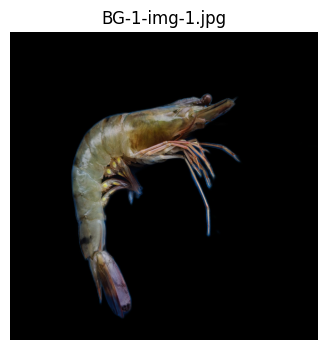

,model_key,model_family,image_path,predicted_label,confidence,latency_ms,prob_Healthy,prob_BG,prob_WSSV,prob_WSSV_BG
0,efficientnet_b0_full_int8,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/P...,BG,1.000000,25.456525,3.059022e-07,1.000000,4.658884e-15,1.125351e-07
1,yolo26n-cls,yolo_ultralytics,/content/drive/MyDrive/shrimp_disease_images/P...,BG,0.998363,7.166119,7.352872e-04,0.998363,5.342751e-04,3.678490e-04
2,efficientnet_b0_float16,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/P...,BG,0.976566,26.159352,3.745290e-03,0.976566,5.494657e-03,1.419424e-02
3,efficientnet_b0_float32,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/P...,BG,0.976421,20.738629,3.909685e-03,0.976421,5.135442e-03,1.453357e-02
4,efficientnet_b0_dynamic_range,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/P...,BG,0.601497,37.214330,9.106640e-02,0.601497,8.749737e-02,2.199394e-01


In [9]:
def predict_one_image(image_path, model_keys=None, show_image=True):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f'Image not found: {image_path}')
    if not MODEL_REGISTRY:
        raise RuntimeError('MODEL_REGISTRY is empty. Check your model paths and rerun discovery.')

    selected_keys = model_keys or list(MODEL_REGISTRY.keys())
    rows = []
    for key in selected_keys:
        record = dict(MODEL_REGISTRY[key])
        record['model_key'] = key
        rows.append(predict_with_record(record, image_path))

    df = pd.DataFrame(rows).sort_values(['confidence', 'model_key'], ascending=[False, True]).reset_index(drop=True)

    if show_image:
        plt.figure(figsize=(4, 4))
        plt.imshow(Image.open(image_path).convert('RGB'))
        plt.axis('off')
        plt.title(image_path.name)
        plt.show()

    return df


# Example: update SINGLE_IMAGE_PATH in the configuration cell, then run this.
single_result = predict_one_image(SINGLE_IMAGE_PATH)
display(single_result)

## Run Inference on a Folder

If your folder is class-organized, for example `.../test/1. Healthy/*.jpg`, the notebook will infer `true_label` from the parent folder and calculate optional accuracy/F1 summaries.

In [10]:
def predict_folder(folder_path, model_keys=None, recursive=True, save_csv=True):
    folder_path = Path(folder_path)
    paths = image_files(folder_path, recursive=recursive)
    if not paths:
        raise FileNotFoundError(f'No image files found under: {folder_path}')
    if not MODEL_REGISTRY:
        raise RuntimeError('MODEL_REGISTRY is empty. Check your model paths and rerun discovery.')

    selected_keys = model_keys or list(MODEL_REGISTRY.keys())
    rows = []
    for image_path in tqdm(paths, desc='Images'):
        true_label = label_from_parent(image_path)
        for key in selected_keys:
            record = dict(MODEL_REGISTRY[key])
            record['model_key'] = key
            row = predict_with_record(record, image_path)
            row['true_label'] = true_label
            rows.append(row)

    df = pd.DataFrame(rows)

    if save_csv:
        timestamp = time.strftime('%Y%m%d_%H%M%S')
        out_path = INFERENCE_OUTPUT_DIR / f'tflite_inference_{timestamp}.csv'
        df.to_csv(out_path, index=False)
        print(f'Saved predictions: {out_path}')

    return df


def summarize_labeled_predictions(prediction_df):
    labeled = prediction_df[prediction_df['true_label'].isin(CLASS_NAMES)].copy()
    if labeled.empty:
        print('No true labels found from parent folders. Returning an empty summary.')
        return pd.DataFrame()

    from sklearn.metrics import accuracy_score, f1_score

    rows = []
    for model_key, group in labeled.groupby('model_key'):
        rows.append({
            'model_key': model_key,
            'n_images': len(group),
            'accuracy': accuracy_score(group['true_label'], group['predicted_label']),
            'macro_f1': f1_score(group['true_label'], group['predicted_label'], labels=CLASS_NAMES, average='macro', zero_division=0),
            'mean_latency_ms': group['latency_ms'].mean(),
        })
    return pd.DataFrame(rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)


# Example: update BATCH_IMAGE_DIR in the configuration cell, then run this.
batch_result = predict_folder(BATCH_IMAGE_DIR)
display(batch_result.head())
display(summarize_labeled_predictions(batch_result))

Images:   0%|          | 0/173 [00:00<?, ?it/s]

Saved predictions: /content/drive/MyDrive/shrimp_disease_images/inference_results/tflite_inference_20260517_062953.csv


,model_key,model_family,image_path,predicted_label,confidence,latency_ms,prob_Healthy,prob_BG,prob_WSSV,prob_WSSV_BG,true_label
0,efficientnet_b0_dynamic_range,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/b...,Healthy,0.460154,38.818163,4.601543e-01,0.253473,9.398489e-02,0.192388,Healthy
1,efficientnet_b0_float16,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/b...,Healthy,0.985415,20.646620,9.854155e-01,0.011973,1.086599e-03,0.001525,Healthy
2,efficientnet_b0_float32,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/b...,Healthy,0.982243,27.121761,9.822428e-01,0.014646,1.204423e-03,0.001907,Healthy
3,efficientnet_b0_full_int8,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/b...,BG,0.880797,18.606589,1.341452e-08,0.880797,9.912064e-08,0.119203,Healthy
4,yolo26n-cls,yolo_ultralytics,/content/drive/MyDrive/shrimp_disease_images/b...,Healthy,0.979964,7.225080,9.799642e-01,0.015580,4.329682e-03,0.000126,Healthy


,model_key,n_images,accuracy,macro_f1,mean_latency_ms
0,yolo26n-cls,173,0.815029,0.804816,8.563615
1,efficientnet_b0_float16,173,0.751445,0.736497,23.175892
2,efficientnet_b0_float32,173,0.745665,0.730999,23.473569
3,efficientnet_b0_dynamic_range,173,0.641618,0.640004,43.736304
4,efficientnet_b0_full_int8,173,0.271676,0.239519,20.735042


## Manual Registry Override

Use this only if automatic discovery does not find a model. Choose `pytorch_imagenet` for MobileNet/EfficientNet models converted from the ONNX files, and `yolo_ultralytics` for YOLO classification TFLite exports.

In [ ]:
# Example manual additions. Uncomment and edit as needed.
# MODEL_REGISTRY['mobilenet_v3_large_float32_manual'] = {
#     'model_key': 'mobilenet_v3_large_float32_manual',
#     'model_name': 'mobilenet_v3_large',
#     'model_family': 'pytorch_imagenet',
#     'path': Path('/content/drive/MyDrive/onnx_models/litert_models/tflite/mobilenet_v3_large_float32.tflite'),
# }
# MODEL_REGISTRY['yolo11n_cls_manual'] = {
#     'model_key': 'yolo11n_cls_manual',
#     'model_name': 'yolo11n-cls',
#     'model_family': 'yolo_ultralytics',
#     'path': Path('/content/drive/MyDrive/shrimp_disease_images/baseline_model_comparison/yolo_runs/yolo11n-cls/weights/best_saved_model/best_float32.tflite'),
# }